<a href="https://colab.research.google.com/github/RolandoLopez16/RegresionLinealHV/blob/main/RegresionLinealHV_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal aplicada a productividad de equipos Harvester

**Archivo:** `RegresionLinealHV.ipynb`  
**Dataset:** `Dataset_HV_2026_v2.xlsx`  
**Caso de estudio:** productividad operacional de equipos harvester en operación forestal 2026.

En este notebook trabajo la regresión lineal como una herramienta interpretable para entender qué variables operativas, técnicas, climáticas y de contexto están asociadas con la productividad final de los equipos harvester, medida en **m³/h**.

La lógica no consiste en “tirar un modelo” sobre los datos. Primero entiendo el negocio, reviso la calidad del dataset, preparo las variables con criterio, evito fuga de información y finalmente interpreto los coeficientes con sentido operativo.

## 1. Comprensión del negocio

La operación mecanizada con harvester depende de muchas condiciones: equipo, marca, zona, contratista, especie, turno, suelo, pendiente, diámetro, volumen de trabajo, paradas y clima. La productividad final en m³/h resume el desempeño operativo, pero por sí sola no explica por qué un equipo rinde más o menos.

**Pregunta de negocio**  
¿Qué variables operativas y de contexto influyen en la productividad final de los equipos harvester durante la operación forestal registrada en 2026?

**Problema analítico**  
Este caso corresponde a un problema de **regresión supervisada**, porque la variable objetivo es continua: productividad en m³/h.

**Decisión metodológica**  
Uso regresión lineal porque permite interpretar coeficientes. En un contexto de negocio, esta ventaja pesa bastante: no solo necesito estimar productividad, también necesito explicar qué variables se asocian con aumentos o reducciones del rendimiento.

## 2. Configuración inicial

Cargo librerías, defino la ruta del archivo y dejo algunas funciones auxiliares para mantener el notebook ordenado. El código está preparado para ejecutarse tanto en un entorno local como en Colab/Jupyter, siempre que el archivo Excel esté en la misma carpeta o en `/mnt/data/`.

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42


FILE_NAME = "Dataset_HV_2026_v2.xlsx"

GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/"
    "RolandoLopez16/RegresionLinealHV/main/Dataset_HV_2026_v2.xlsx"
)

possible_paths = [
    f"/mnt/data/{FILE_NAME}",     # Entorno ChatGPT / sandbox
    FILE_NAME,                    # Misma carpeta del notebook
    f"./{FILE_NAME}",             # Ruta relativa local
    f"/content/{FILE_NAME}",      # Google Colab
]

DATA_PATH = next((p for p in possible_paths if os.path.exists(p)), None)

if DATA_PATH is not None:
    print(f"Dataset cargado desde archivo local: {DATA_PATH}")
    df = pd.read_excel(DATA_PATH)
else:
    print("No se encontró archivo local. Cargando dataset desde GitHub RAW...")
    DATA_PATH = GITHUB_RAW_URL
    df = pd.read_excel(DATA_PATH)

print(f"Ruta o fuente utilizada: {DATA_PATH}")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

df.head()

No se encontró archivo local. Cargando dataset desde GitHub RAW...
Ruta o fuente utilizada: https://raw.githubusercontent.com/RolandoLopez16/RegresionLinealHV/main/Dataset_HV_2026_v2.xlsx
Dimensiones del dataset: 1645 filas x 64 columnas


,E%,E% Global,DM%,ARB/HORA,VOL/ÁRBOL,PRODUCTIVIDAD M3/H,T EFECTIVO,Horas disponibles,Ttal P. mec,Mantenimiento periódico,T Paradas Mec Mantenimiento,Total horas de otras paradas,EQUIPO,MARCA,OPERADOR,CEDULA,ZONA,CONTRATISTA,FECHA,FINCA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,Longitud Sexa finca,Latitud Sexa finca,Municipio Finca,PENDIENTE PROMEDIO FINCA,ESPECIE,LOTE,TURNO,HORA INICIO TURNO,HORA FIN TURNO,PENDIENTE,TOTAL DE ARBOLES,M3,M3/HORA,FUSTES/HORA,DIAMETRO,T PROGRAMADO,T PARADAS MEC,ESPECIFICACION PARADA,REF REPUESTO,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,NOVEDADES,SUELO,HORAS DE OTRAS PARADA,T OTRA PARADA 1,T OTRA PARADA2,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5
0,0.000,0.000,1.000,NaN,NaN,NaN,0.000,8.000,0.000,0.000,0.000,8.000,HVPO-1,PONSSE,ELBER GRANADA,"15,961,194.000",NORTE,GREEN FOREST,2026-01-01,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,8.000,8.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
1,0.000,0.000,1.000,NaN,NaN,NaN,0.000,7.000,0.000,0.000,0.000,7.000,HVPO-1,PONSSE,JOSE MORENO,"94,282,613.000",NORTE,GREEN FOREST,2026-01-01,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 2,14:00:00,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,7.000,7.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
2,0.000,0.000,1.000,NaN,NaN,NaN,0.000,8.000,0.000,0.000,0.000,8.000,HVPO-5,PONSSE,NAPOLEON OROZCO,"94,266,396.000",NORTE,GREEN FOREST,2026-01-01,13CRIST,15.200,10.700,20.100,13.300,8.500,0.000,0,0,75°51'47.2''W,4°07'04.0''N,Sevilla,35.031,Pinus maximinoi,8,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OPERADOR EN DIA DE RECESO POR NAVIDAD,HUMEDO,8.000,8.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
3,0.000,0.000,1.000,NaN,NaN,NaN,0.000,7.000,0.000,0.000,0.000,7.000,HVPO-5,PONSSE,JORGE HERNANDEZ,"1,059,706,760.000",NORTE,GREEN FOREST,2026-01-01,13CRIST,15.200,10.700,20.100,13.300,8.500,0.000,0,0,75°51'47.2''W,4°07'04.0''N,Sevilla,35.031,Pinus maximinoi,8,TURNO 2,14:00:00,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OPERADOR EN DIA DE RECESO POR NAVIDAD,HUMEDO,7.000,7.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
4,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,8.000,0.000,0.000,0.000,HVPO-1,PONSSE,ELBER GRANADA,"15,961,194.000",NORTE,GREEN FOREST,2026-01-02,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Comprensión de los datos

Leo el archivo Excel, identifico la hoja disponible y reviso la estructura general. Esta parte confirma cuántos registros tenemos, cuántas variables existen y qué tipos de datos predominan.

In [4]:
excel_file = pd.ExcelFile(DATA_PATH)
excel_file.sheet_names

['INFORMEHV']

In [5]:
sheet_name = "INFORMEHV" if "INFORMEHV" in excel_file.sheet_names else excel_file.sheet_names[0]
df_raw = pd.read_excel(DATA_PATH, sheet_name=sheet_name)

print(f"Hoja utilizada: {sheet_name}")
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")
df_raw.head()

Hoja utilizada: INFORMEHV
Filas: 1,645
Columnas: 64


,E%,E% Global,DM%,ARB/HORA,VOL/ÁRBOL,PRODUCTIVIDAD M3/H,T EFECTIVO,Horas disponibles,Ttal P. mec,Mantenimiento periódico,T Paradas Mec Mantenimiento,Total horas de otras paradas,EQUIPO,MARCA,OPERADOR,CEDULA,ZONA,CONTRATISTA,FECHA,FINCA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,Longitud Sexa finca,Latitud Sexa finca,Municipio Finca,PENDIENTE PROMEDIO FINCA,ESPECIE,LOTE,TURNO,HORA INICIO TURNO,HORA FIN TURNO,PENDIENTE,TOTAL DE ARBOLES,M3,M3/HORA,FUSTES/HORA,DIAMETRO,T PROGRAMADO,T PARADAS MEC,ESPECIFICACION PARADA,REF REPUESTO,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,NOVEDADES,SUELO,HORAS DE OTRAS PARADA,T OTRA PARADA 1,T OTRA PARADA2,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5
0,0.000,0.000,1.000,NaN,NaN,NaN,0.000,8.000,0.000,0.000,0.000,8.000,HVPO-1,PONSSE,ELBER GRANADA,"15,961,194.000",NORTE,GREEN FOREST,2026-01-01,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,8.000,8.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
1,0.000,0.000,1.000,NaN,NaN,NaN,0.000,7.000,0.000,0.000,0.000,7.000,HVPO-1,PONSSE,JOSE MORENO,"94,282,613.000",NORTE,GREEN FOREST,2026-01-01,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 2,14:00:00,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,7.000,7.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
2,0.000,0.000,1.000,NaN,NaN,NaN,0.000,8.000,0.000,0.000,0.000,8.000,HVPO-5,PONSSE,NAPOLEON OROZCO,"94,266,396.000",NORTE,GREEN FOREST,2026-01-01,13CRIST,15.200,10.700,20.100,13.300,8.500,0.000,0,0,75°51'47.2''W,4°07'04.0''N,Sevilla,35.031,Pinus maximinoi,8,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OPERADOR EN DIA DE RECESO POR NAVIDAD,HUMEDO,8.000,8.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
3,0.000,0.000,1.000,NaN,NaN,NaN,0.000,7.000,0.000,0.000,0.000,7.000,HVPO-5,PONSSE,JORGE HERNANDEZ,"1,059,706,760.000",NORTE,GREEN FOREST,2026-01-01,13CRIST,15.200,10.700,20.100,13.300,8.500,0.000,0,0,75°51'47.2''W,4°07'04.0''N,Sevilla,35.031,Pinus maximinoi,8,TURNO 2,14:00:00,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OPERADOR EN DIA DE RECESO POR NAVIDAD,HUMEDO,7.000,7.000,NaN,NaN,NaN,NaN,Receso Año nuevo,NaN,NaN,NaN,NaN
4,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,8.000,0.000,0.000,0.000,HVPO-1,PONSSE,ELBER GRANADA,"15,961,194.000",NORTE,GREEN FOREST,2026-01-02,13INDOS,17.400,12.900,22.900,22.100,10.000,0.000,0,0,75°50'28.7''W,4°10'32.5''N,Sevilla,29.075,Eucalyptus grandis,15,TURNO 1,06:00:00,14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,INOPERATIVO POR PASO DE LÍQUIDO REFRIGERANTE A...,HUMEDO,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
resumen_estructura = pd.DataFrame({
    "variable": df_raw.columns,
    "tipo_dato": df_raw.dtypes.astype(str).values,
    "nulos": df_raw.isna().sum().values,
    "porcentaje_nulos": (df_raw.isna().mean().values * 100).round(2),
    "valores_unicos": [df_raw[c].nunique(dropna=True) for c in df_raw.columns]
}).sort_values("porcentaje_nulos", ascending=False)

resumen_estructura.head(20)

,variable,tipo_dato,nulos,porcentaje_nulos,valores_unicos
63,MOTIVO 5,float64,1645,100.000,0
62,MOTIVO 4,object,1643,99.880,2
61,MOTIVO 3,object,1635,99.390,7
58,T OTRA PARADA 5,float64,1628,98.970,1
57,T OTRA PARADA 4,float64,1625,98.780,4
56,T OTRA PARADA3,float64,1615,98.180,10
60,MOTIVO 2,object,1540,93.620,28
55,T OTRA PARADA2,float64,1523,92.580,61
41,FUSTES/HORA,float64,1169,71.060,153
59,MOTIVO 1,object,1147,69.730,83


## 4. Definición de la variable objetivo

Para este proyecto tomo como variable objetivo **`PRODUCTIVIDAD M3/H`**, porque representa directamente la productividad final en m³/h desde el informe consolidado.

También existe `M3/HORA`, pero presenta valores extremos muy altos en el dataset. Por eso no la uso como objetivo principal ni como predictor. Esta decisión evita que el modelo aprenda sobre una variable inconsistente o derivada de la misma lógica de productividad.

In [7]:
target_col = "PRODUCTIVIDAD M3/H"

if target_col not in df_raw.columns:
    raise ValueError(f"No encuentro la variable objetivo esperada: {target_col}")

df_raw[target_col].describe()

,PRODUCTIVIDAD M3/H
count,"1,322.000"
mean,13.321
std,7.941
min,0.000
25%,8.453
50%,12.255
75%,17.693
max,77.360


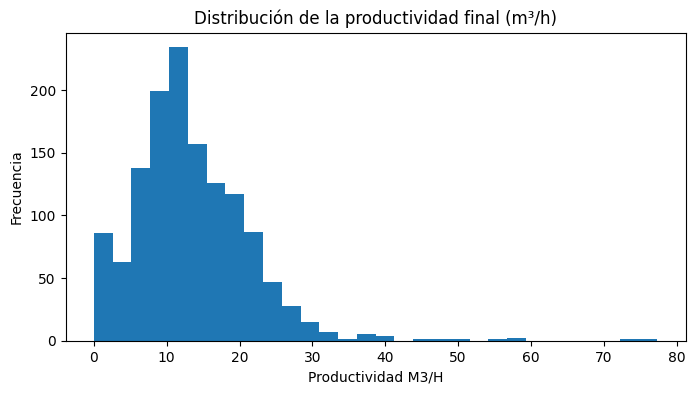

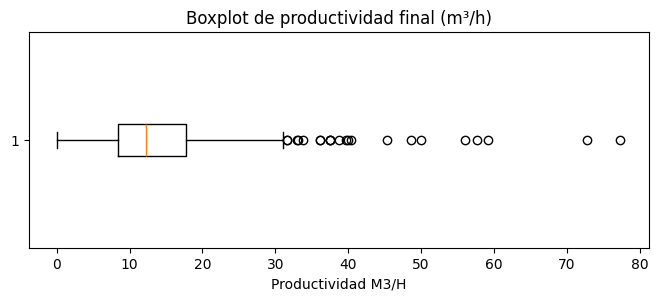

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(df_raw[target_col].dropna(), bins=30)
plt.title("Distribución de la productividad final (m³/h)")
plt.xlabel("Productividad M3/H")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 2.8))
plt.boxplot(df_raw[target_col].dropna(), vert=False)
plt.title("Boxplot de productividad final (m³/h)")
plt.xlabel("Productividad M3/H")
plt.show()

## 5. Limpieza inicial y control de calidad

Antes de modelar, depuro el dataset con reglas transparentes:

- Elimino registros sin variable objetivo, porque no sirven para entrenar un modelo supervisado.
- Quito duplicados exactos si existen.
- Conservo registros con productividad igual a cero solo si están presentes; operativamente pueden representar días o turnos sin producción. Más adelante reviso si conviene excluirlos en un análisis alternativo.
- No uso variables que puedan generar fuga de información, como producción total o métricas calculadas directamente desde la productividad.

In [9]:
df = df_raw.copy()

duplicados = df.duplicated().sum()
print(f"Duplicados exactos detectados: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates().copy()

antes = len(df)
df = df[df[target_col].notna()].copy()
despues = len(df)
print(f"Registros eliminados por objetivo nulo: {antes - despues}")
print(f"Registros disponibles para modelado: {len(df):,}")

Duplicados exactos detectados: 10
Registros eliminados por objetivo nulo: 318
Registros disponibles para modelado: 1,317


In [10]:
# Revisión rápida de valores extremos de la variable objetivo mediante IQR.
q1 = df[target_col].quantile(0.25)
q3 = df[target_col].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_target = df[(df[target_col] < limite_inferior) | (df[target_col] > limite_superior)]

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Outliers potenciales en productividad: {len(outliers_target)}")

outliers_target[[target_col, "EQUIPO", "MARCA", "ZONA", "CONTRATISTA", "FECHA"]].head(10)

Q1: 8.46
Q3: 17.64
IQR: 9.18
Límite inferior: -5.31
Límite superior: 31.41
Outliers potenciales en productividad: 22


,PRODUCTIVIDAD M3/H,EQUIPO,MARCA,ZONA,CONTRATISTA,FECHA
178,32.910,HVPO-2,PONSSE,Norte,EFAGRAM,2026-01-04
260,50.000,HVJD-2,JOHN DEER,CENTRO,EFAGRAM,2026-01-18
396,37.560,HVJD-4,JOHN DEER,CENTRO,AMBAR,2026-01-25
543,39.740,HVPO-3,PONSSE,NORTE,EFAGRAM,2026-02-01
670,38.690,HVPO-4,PONSSE,CENTRO,EFAGRAM,2026-02-10
823,36.170,HVJD-3,JOHN DEER,CENTRO,EFAGRAM,2026-02-19
931,40.000,HVPO-3,PONSSE,NORTE,EFAGRAM,2026-03-02
997,40.380,HVJD-2,JOHN DEER,CENTRO,EFAGRAM,2026-03-07
1017,33.810,HVPO-3,PONSSE,NORTE,EFAGRAM,2026-03-08
1034,31.640,HVPO-5,PONSSE,NORTE,GREEN FOREST,2026-03-04


## 6. Selección de variables predictoras

Selecciono variables con sentido operativo y evito variables derivadas de la productividad. Esta decisión es clave: si incluyo `M3`, `M3/HORA`, `ARB/HORA`, `VOL/ÁRBOL` o métricas calculadas directamente desde desempeño, el modelo puede inflar sus resultados sin aportar una explicación válida.

### Variables categóricas seleccionadas
- `EQUIPO`
- `MARCA`
- `ZONA`
- `CONTRATISTA`
- `FINCA`
- `Municipio Finca`
- `ESPECIE`
- `TURNO`
- `SUELO`

### Variables numéricas seleccionadas
- `PENDIENTE PROMEDIO FINCA`
- `PENDIENTE`
- `TOTAL DE ARBOLES`
- `DIAMETRO`
- `T PROGRAMADO`
- `T PARADAS MEC`
- `T USO WINCHE`
- `HORAS DE OTRAS PARADA`
- Variables climáticas: temperatura, precipitación, viento, presión y horas de lluvia.

In [11]:
categorical_candidates = [
    "EQUIPO", "MARCA", "ZONA", "CONTRATISTA", "FINCA", "Municipio Finca",
    "ESPECIE", "TURNO", "SUELO"
]

numeric_candidates = [
    "PENDIENTE PROMEDIO FINCA", "PENDIENTE", "TOTAL DE ARBOLES", "DIAMETRO",
    "T PROGRAMADO", "T PARADAS MEC", "T USO WINCHE", "HORAS DE OTRAS PARADA",
    "clima_temp_promedio_dia_c", "clima_temp_min_dia_c", "clima_temp_max_dia_c",
    "clima_precipitacion_dia_mm", "clima_viento_promedio_dia_kmh",
    "clima_presion_promedio_dia_hpa", "clima_horas_validas_dia", "clima_horas_lluvia_dia"
]

categorical_features = [c for c in categorical_candidates if c in df.columns]
numeric_features = [c for c in numeric_candidates if c in df.columns]

print("Variables categóricas usadas:")
print(categorical_features)
print("\nVariables numéricas usadas:")
print(numeric_features)
print(f"\nTotal de predictores base: {len(categorical_features) + len(numeric_features)}")

Variables categóricas usadas:
['EQUIPO', 'MARCA', 'ZONA', 'CONTRATISTA', 'FINCA', 'Municipio Finca', 'ESPECIE', 'TURNO', 'SUELO']

Variables numéricas usadas:
['PENDIENTE PROMEDIO FINCA', 'PENDIENTE', 'TOTAL DE ARBOLES', 'DIAMETRO', 'T PROGRAMADO', 'T PARADAS MEC', 'T USO WINCHE', 'HORAS DE OTRAS PARADA', 'clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa', 'clima_horas_validas_dia', 'clima_horas_lluvia_dia']

Total de predictores base: 25


In [12]:
# Conversión defensiva: si alguna variable numérica llegó como texto, intento convertirla.
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Limpieza de texto en variables categóricas.
for col in categorical_features:
    df[col] = df[col].astype("object").where(df[col].notna(), np.nan)
    df[col] = df[col].astype("object").apply(lambda x: x.strip().upper() if isinstance(x, str) else x)

# Tabla de cardinalidad para entender cuántas categorías entrarán al One-Hot Encoding.
cardinalidad = pd.DataFrame({
    "variable": categorical_features,
    "categorias_unicas": [df[c].nunique(dropna=True) for c in categorical_features],
    "nulos": [df[c].isna().sum() for c in categorical_features]
}).sort_values("categorias_unicas", ascending=False)

cardinalidad

,variable,categorias_unicas,nulos
4,FINCA,37,0
5,Municipio Finca,12,0
0,EQUIPO,10,0
6,ESPECIE,10,0
2,ZONA,3,0
7,TURNO,3,0
3,CONTRATISTA,3,0
8,SUELO,3,22
1,MARCA,2,0


## 7. Análisis exploratorio enfocado en el modelado

Aquí reviso relaciones iniciales entre predictores y productividad. El objetivo no es concluir todavía, sino detectar señales, inconsistencias y posibles variables influyentes.

In [13]:
# Correlaciones entre variables numéricas y productividad.
corr_data = df[[target_col] + numeric_features].corr(numeric_only=True)[target_col].drop(target_col)
corr_data = corr_data.sort_values(key=lambda s: s.abs(), ascending=False)

corr_data.to_frame("correlacion_con_productividad")

,correlacion_con_productividad
TOTAL DE ARBOLES,0.344
T PROGRAMADO,-0.115
DIAMETRO,0.071
clima_temp_min_dia_c,0.065
clima_presion_promedio_dia_hpa,0.046
clima_temp_promedio_dia_c,0.046
T USO WINCHE,0.041
clima_precipitacion_dia_mm,-0.036
HORAS DE OTRAS PARADA,-0.032
clima_temp_max_dia_c,0.029


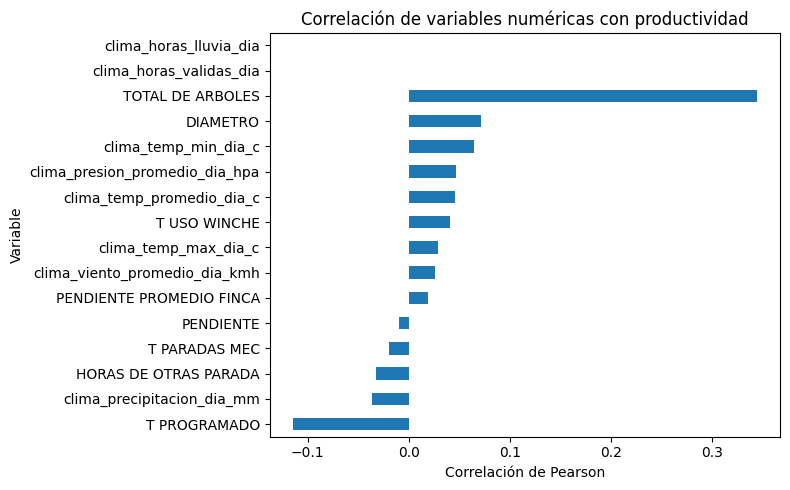

In [14]:
plt.figure(figsize=(8, 5))
corr_data.sort_values().plot(kind="barh")
plt.title("Correlación de variables numéricas con productividad")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [15]:
# Productividad promedio por algunas variables categóricas de negocio.
for col in ["MARCA", "ZONA", "TURNO", "SUELO", "ESPECIE"]:
    if col in categorical_features:
        resumen = (
            df.groupby(col)[target_col]
            .agg(registros="count", promedio="mean", mediana="median", desviacion="std")
            .sort_values("promedio", ascending=False)
        )
        display(resumen.head(12))

,registros,promedio,mediana,desviacion
MARCA,,,,
JOHN DEER,727,14.300,13.230,7.557
PONSSE,590,12.127,10.950,8.242


,registros,promedio,mediana,desviacion
ZONA,,,,
CENTRO,657,14.462,13.080,7.686
NORTE,534,12.280,11.220,8.384
SUR,126,11.846,11.735,6.372


,registros,promedio,mediana,desviacion
TURNO,,,,
TURNO 2,596,13.878,12.415,8.603
TURNO 1,702,12.906,12.175,7.376
TURNO 3,19,11.589,11.470,5.124


,registros,promedio,mediana,desviacion
SUELO,,,,
SECO,479,14.059,13.220,7.546
HUMEDO,815,12.860,11.760,8.159
HAROLD OROZCO \nEQUIPO CON PLUMILLAS MALAS DIFICULTANDO VISIBILIDAD POR LLUVIAS EN LA JORNADA,1,5.260,5.260,NaN


,registros,promedio,mediana,desviacion
ESPECIE,,,,
PINO PÁTULA,51,21.003,21.600,7.000
PINO TECUNUMANII,191,15.017,15.040,7.988
EUCALYPTUS UROGRANDIS,86,14.477,13.830,5.950
PINO KESIYA,16,14.287,12.355,8.583
PINUS TECUNUMANII,159,14.020,11.840,7.490
PINUS MAXIMINOI,117,13.833,14.150,5.348
EUCALIPTO GRANDIS,234,12.679,11.325,10.232
EUCALYPTUS GRANDIS,339,12.023,10.780,6.726
PINO MAXIMINO,23,11.773,9.800,9.325


## 8. Preparación del dataset para regresión lineal

La regresión lineal necesita variables numéricas. Por eso preparo dos flujos:

- A las variables numéricas les aplico imputación por mediana y luego `StandardScaler`.
- A las variables categóricas les aplico imputación por categoría frecuente y luego `One-Hot Encoding` con eliminación de una categoría base (`drop='first'`).

La estandarización permite comparar coeficientes numéricos en una escala común. El One-Hot Encoding permite incluir categorías sin convertirlas en números ordinales falsos.

In [16]:
X = df[categorical_features + numeric_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

def make_model():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    try:
        onehot = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

model = make_model()

print(f"Entrenamiento: {X_train.shape[0]:,} registros")
print(f"Prueba: {X_test.shape[0]:,} registros")

Entrenamiento: 1,053 registros
Prueba: 264 registros


## 9. Entrenamiento del modelo

Entreno la regresión lineal con el conjunto de entrenamiento y evalúo con datos no vistos. Las métricas principales son:

- **MAE:** error absoluto promedio en m³/h. Es la métrica más clara para negocio.
- **RMSE:** penaliza más los errores grandes.
- **R²:** indica qué proporción de variabilidad queda explicada por el modelo.

In [17]:
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.Series({"MAE": mae, "RMSE": rmse, "R2": r2})

metricas = pd.DataFrame({
    "Entrenamiento": regression_metrics(y_train, y_pred_train),
    "Prueba": regression_metrics(y_test, y_pred_test)
}).T

metricas

,MAE,RMSE,R2
Entrenamiento,4.195,6.489,0.333
Prueba,3.986,6.779,0.268


## 10. Validación cruzada K-Fold

La partición entrenamiento/prueba puede depender de cómo quedaron separados los registros. Para reducir ese riesgo, aplico validación cruzada con 10 particiones. Esta validación permite revisar la estabilidad del error y tener una lectura más confiable del desempeño esperado.

In [18]:
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model, X, y,
    cv=kfold,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "R2"],
    "promedio": [
        -cv_results["test_MAE"].mean(),
        -cv_results["test_RMSE"].mean(),
        cv_results["test_R2"].mean()
    ],
    "desviacion": [
        cv_results["test_MAE"].std(),
        cv_results["test_RMSE"].std(),
        cv_results["test_R2"].std()
    ]
})

cv_summary

,metrica,promedio,desviacion
0,MAE,4.332,0.358
1,RMSE,6.827,1.067
2,R2,0.245,0.128


## 11. Interpretación de coeficientes

La regresión lineal permite leer la dirección e intensidad de asociación de cada predictor con la productividad.

- Coeficiente positivo: la variable se asocia con mayor productividad esperada, manteniendo las demás constantes.
- Coeficiente negativo: la variable se asocia con menor productividad esperada, manteniendo las demás constantes.
- En variables categóricas, cada coeficiente compara una categoría contra la categoría base eliminada por One-Hot Encoding.

Esta interpretación es asociativa, no causal. Un coeficiente no prueba causalidad; entrega una señal cuantitativa útil para decisión operativa.

In [19]:
# Recupero nombres finales después de StandardScaler y One-Hot Encoding.
fitted_preprocessor = model.named_steps["preprocessor"]

feature_names = []
feature_names.extend(numeric_features)

if categorical_features:
    cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_names)

coefs = model.named_steps["regressor"].coef_
coef_df = pd.DataFrame({
    "variable": feature_names,
    "coeficiente": coefs
})
coef_df["impacto_abs"] = coef_df["coeficiente"].abs()
coef_df = coef_df.sort_values("impacto_abs", ascending=False)

coef_df.head(25)

,variable,coeficiente,impacto_abs
34,FINCA_13ALSAC,-6.028,6.028
37,FINCA_13CRIST,5.569,5.569
18,EQUIPO_HVJD-4,5.509,5.509
42,FINCA_13SINAB,4.615,4.615
46,FINCA_31ALASK,4.481,4.481
66,Municipio Finca_CAICEDONIA,4.300,4.300
41,FINCA_13SIBER,4.300,4.300
35,FINCA_13AMPAR,-4.270,4.270
2,TOTAL DE ARBOLES,3.969,3.969
49,FINCA_31PALES,-3.925,3.925


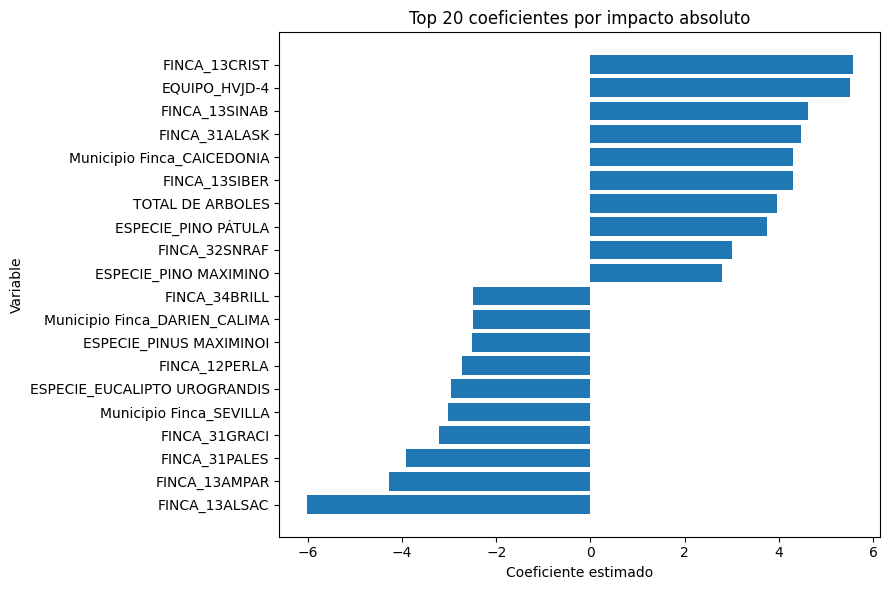

In [20]:
top_n = 20
top_coef = coef_df.head(top_n).sort_values("coeficiente")

plt.figure(figsize=(9, 6))
plt.barh(top_coef["variable"], top_coef["coeficiente"])
plt.title(f"Top {top_n} coeficientes por impacto absoluto")
plt.xlabel("Coeficiente estimado")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 12. Diagnóstico de residuos

Reviso residuos para evaluar si el modelo presenta patrones fuertes de error. En una regresión lineal interpretable, estos gráficos ayudan a detectar problemas como no linealidad, heterocedasticidad o errores extremos.

In [21]:
residuos = y_test - y_pred_test

diagnostico = pd.DataFrame({
    "y_real": y_test.values,
    "y_predicho": y_pred_test,
    "residuo": residuos.values
})

diagnostico.head()

,y_real,y_predicho,residuo
0,24.710,17.222,7.488
1,7.060,10.902,-3.842
2,12.890,14.420,-1.530
3,4.320,6.405,-2.085
4,20.280,11.798,8.482


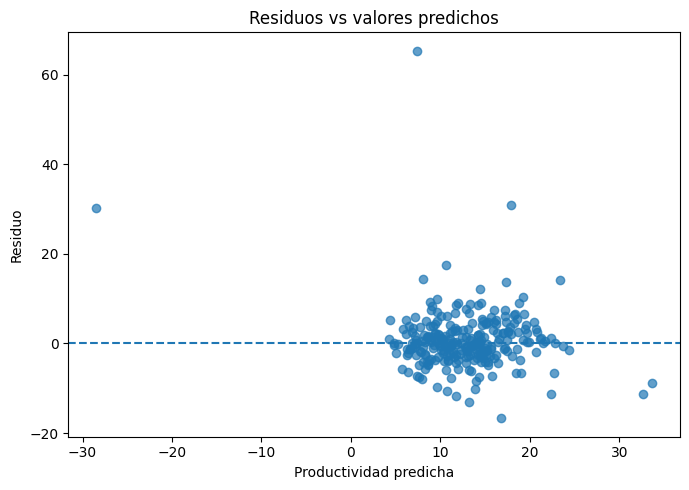

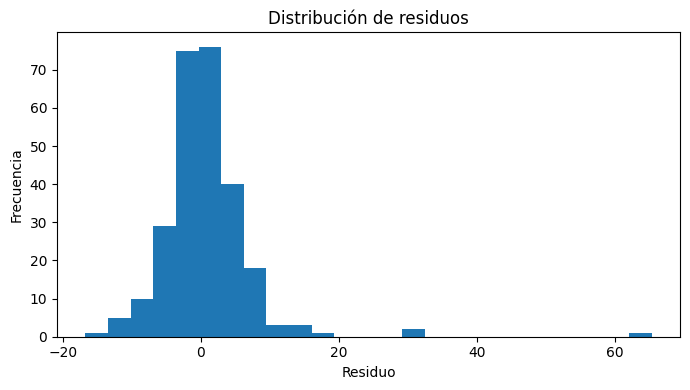

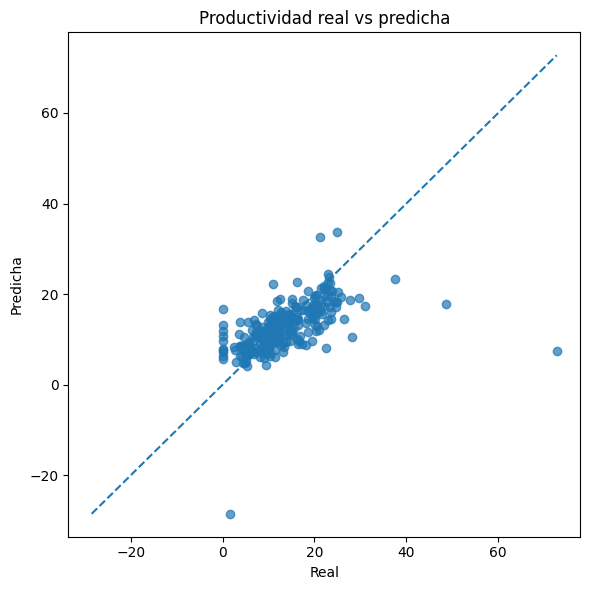

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(diagnostico["y_predicho"], diagnostico["residuo"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residuos vs valores predichos")
plt.xlabel("Productividad predicha")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(diagnostico["residuo"], bins=25)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(diagnostico["y_real"], diagnostico["y_predicho"], alpha=0.7)
min_val = min(diagnostico["y_real"].min(), diagnostico["y_predicho"].min())
max_val = max(diagnostico["y_real"].max(), diagnostico["y_predicho"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Productividad real vs predicha")
plt.xlabel("Real")
plt.ylabel("Predicha")
plt.tight_layout()
plt.show()

## 13. Análisis alternativo sin productividades cero

En operación forestal, una productividad igual a cero puede representar inactividad, falla, receso o ausencia de producción. Eso tiene valor operativo, pero puede afectar la lectura de una regresión enfocada en condiciones de producción activa.

Por eso ejecuto una comparación opcional: modelo con registros donde la productividad es mayor a cero. No reemplaza el modelo principal; sirve para contrastar estabilidad de resultados.

In [23]:
df_activo = df[df[target_col] > 0].copy()
print(f"Registros con productividad > 0: {len(df_activo):,}")

if len(df_activo) >= 50:
    X_activo = df_activo[categorical_features + numeric_features].copy()
    y_activo = df_activo[target_col].copy()

    X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
        X_activo, y_activo, test_size=0.20, random_state=RANDOM_STATE
    )

    model_activo = make_model()

    model_activo.fit(X_train_a, y_train_a)
    y_pred_a = model_activo.predict(X_test_a)

    metricas_activas = regression_metrics(y_test_a, y_pred_a).to_frame("Modelo solo producción activa").T
    display(metricas_activas)
else:
    print("No hay suficientes registros para entrenar el análisis alternativo.")

Registros con productividad > 0: 1,250


,MAE,RMSE,R2
Modelo solo producción activa,3.490,5.502,0.190


## 14. Predicción de un escenario operativo

Esta sección muestra cómo usar el modelo para estimar la productividad de un nuevo escenario. Tomo como ejemplo un registro real del conjunto de prueba, lo paso por el modelo y comparo la predicción con el valor observado.

In [24]:
ejemplo = X_test.iloc[[0]].copy()
prediccion = model.predict(ejemplo)[0]
real = y_test.iloc[0]

print("Escenario usado para ejemplo:")
display(ejemplo)

print(f"Productividad real: {real:.2f} m³/h")
print(f"Productividad estimada: {prediccion:.2f} m³/h")
print(f"Error absoluto: {abs(real - prediccion):.2f} m³/h")

Escenario usado para ejemplo:


,EQUIPO,MARCA,ZONA,CONTRATISTA,FINCA,Municipio Finca,ESPECIE,TURNO,SUELO,PENDIENTE PROMEDIO FINCA,PENDIENTE,TOTAL DE ARBOLES,DIAMETRO,T PROGRAMADO,T PARADAS MEC,T USO WINCHE,HORAS DE OTRAS PARADA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia
328,HVJD-4,JOHN DEER,CENTRO,AMBAR,31ESMER,RIOFRIO,PINUS TECUNUMANII,TURNO 1,HUMEDO,16.865,27.000,70.000,29.000,8.000,1.470,4.430,3.447,16.200,14.100,19.200,7.400,9.700,0.000,0,0


Productividad real: 24.71 m³/h
Productividad estimada: 17.22 m³/h
Error absoluto: 7.49 m³/h


## 15. Lectura de negocio

Con este modelo puedo convertir el histórico operacional en criterios de decisión. La utilidad no está solo en predecir un número, sino en ordenar señales para la gestión:

- Comparar equipos o marcas controlando zona, especie, suelo, turno y clima.
- Detectar condiciones asociadas con menor productividad.
- Evaluar si las paradas, el uso de winche o la pendiente están afectando el rendimiento.
- Anticipar escenarios donde la productividad esperada puede ser baja.
- Priorizar acciones sobre variables modificables: programación, reducción de paradas, asignación de equipo y planificación por zona.

La lectura responsable es clara: los coeficientes indican asociación, no causalidad definitiva. Para afirmar causalidad haría falta un diseño experimental o controles adicionales que no están garantizados en este dataset.

## 16. Conclusiones

1. La regresión lineal es adecuada como primer modelo porque la variable objetivo es continua y porque el proyecto necesita interpretación.
2. El dataset permite trabajar una matriz de predictores con variables operativas, categóricas, técnicas y climáticas.
3. La preparación de datos es obligatoria: One-Hot Encoding para categóricas y StandardScaler para numéricas.
4. El MAE es la métrica principal porque traduce el error directamente a m³/h, una unidad que el negocio entiende.
5. La interpretación de coeficientes permite identificar variables asociadas con mayor o menor productividad, siempre bajo una lectura asociativa y no causal.
6. El modelo sirve como base para decisiones de asignación de maquinaria, análisis de desempeño y planeación operativa.

## 17. Guardado de resultados opcional

Esta celda exporta tablas útiles para anexos: métricas, coeficientes y predicciones del conjunto de prueba.

In [25]:
output_dir = "resultados_regresion_hv"
os.makedirs(output_dir, exist_ok=True)

metricas.to_csv(os.path.join(output_dir, "metricas_train_test.csv"), index=True, encoding="utf-8-sig")
cv_summary.to_csv(os.path.join(output_dir, "metricas_validacion_cruzada.csv"), index=False, encoding="utf-8-sig")
coef_df.to_csv(os.path.join(output_dir, "coeficientes_regresion_lineal.csv"), index=False, encoding="utf-8-sig")
diagnostico.to_csv(os.path.join(output_dir, "predicciones_y_residuos_prueba.csv"), index=False, encoding="utf-8-sig")

print(f"Resultados guardados en la carpeta: {output_dir}")

Resultados guardados en la carpeta: resultados_regresion_hv
